# **Klasifikasi Karakter Status Hidup/Mati dari serial Game of Thrones | Decision Tree**

Model klasifikasi status hidup/mati dalam serial game of Thrones berdasarkan karakteristik tertentu menggunakan algoritma Decision Tree.

## **1. Data Understanding**

### 1.1 Import Library

In [271]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Read Dataset

In [272]:
# Import 'HW2' dataset 
game = pd.read_csv('HW2.csv')

# Show the top 5 rows of dataset 
print('\nShow the top 5 rows of dataset:')
game.head()


Show the top 5 rows of dataset:


,S.No,plod,name,title,gender,culture,dateOfBirth,DateoFdeath,mother,father,...,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,boolDeadRelations,isPopular,popularity,isAlive
0,1,0.946,Viserys II Targaryen,NaN,1,NaN,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,...,0.0,NaN,0,0,NaN,11,1,1,0.605351,0
1,2,0.613,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,...,NaN,1.0,1,1,97.0,1,1,1,0.896321,1
2,3,0.507,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,1,NaN,0,0,0,0.267559,1
3,4,0.924,Aemma Arryn,Queen,0,NaN,82.0,105.0,NaN,NaN,...,NaN,0.0,1,1,23.0,0,0,0,0.183946,0
4,5,0.383,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,...,NaN,1.0,1,1,29.0,0,0,0,0.043478,1


In [273]:
# Show the information of dataset
print('\nInformation of dataset:')
game.info()


Information of dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1946 entries, 0 to 1945
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No               1946 non-null   int64  
 1   plod               1946 non-null   float64
 2   name               1946 non-null   str    
 3   title              938 non-null    str    
 4   gender             1946 non-null   int64  
 5   culture            677 non-null    str    
 6   dateOfBirth        433 non-null    float64
 7   DateoFdeath        444 non-null    float64
 8   mother             21 non-null     str    
 9   father             26 non-null     str    
 10  heir               23 non-null     str    
 11  house              1519 non-null   str    
 12  spouse             276 non-null    str    
 13  book1              1946 non-null   int64  
 14  book2              1946 non-null   int64  
 15  book3              1946 non-null   int64  
 16  book4     

In [274]:
# Show the dimensional data of daataset
print('\nDimensional data of dataset:')
print('Number of rows:', game.shape[0])
print('Number of columns:', game.shape[1])


Dimensional data of dataset:
Number of rows: 1946
Number of columns: 30


In [275]:
# Show the number of unique values 
print('\nNumber of unique values:')
game.nunique()


Number of unique values:


S.No                 1946
plod                  693
name                 1946
title                 262
gender                  2
culture                64
dateOfBirth           134
DateoFdeath            69
mother                 17
father                 20
heir                   22
house                 347
spouse                254
book1                   2
book2                   2
book3                   2
book4                   2
book5                   2
isAliveMother           2
isAliveFather           2
isAliveHeir             2
isAliveSpouse           2
isMarried               2
isNoble                 2
age                    85
numDeadRelations       14
boolDeadRelations       2
isPopular               2
popularity            166
isAlive                 2
dtype: int64

In [276]:
# Drop 'S.No' and 'title' features
features = ['S.No' ,'name']
game = game.drop(features, axis=1)
game.columns

Index(['plod', 'title', 'gender', 'culture', 'dateOfBirth', 'DateoFdeath',
       'mother', 'father', 'heir', 'house', 'spouse', 'book1', 'book2',
       'book3', 'book4', 'book5', 'isAliveMother', 'isAliveFather',
       'isAliveHeir', 'isAliveSpouse', 'isMarried', 'isNoble', 'age',
       'numDeadRelations', 'boolDeadRelations', 'isPopular', 'popularity',
       'isAlive'],
      dtype='str')

In [277]:
# Separate the numerical and categorical features
num_cols = game.select_dtypes(include='number')
cat_cols = game.select_dtypes(include=['object', 'category'])

print('\nNumerical featrues:', num_cols.columns.tolist())
print('Categorical features:', cat_cols.columns.tolist())


Numerical featrues: ['plod', 'gender', 'dateOfBirth', 'DateoFdeath', 'book1', 'book2', 'book3', 'book4', 'book5', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'isMarried', 'isNoble', 'age', 'numDeadRelations', 'boolDeadRelations', 'isPopular', 'popularity', 'isAlive']
Categorical features: ['title', 'culture', 'mother', 'father', 'heir', 'house', 'spouse']


/tmp/ipykernel_51120/2342357481.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = game.select_dtypes(include=['object', 'category'])


In [278]:
# Show the number of missing value and duplicated data
print('\nNumber of missing value:', game.isnull().sum().sum())
print('Number of duplicated data:', game.duplicated().sum())


Number of missing value: 22108
Number of duplicated data: 27


In [279]:
# Show number of missing value per columns
print('\nNumber of missing value per features')
game.isnull().sum()


Number of missing value per features


plod                    0
title                1008
gender                  0
culture              1269
dateOfBirth          1513
DateoFdeath          1502
mother               1925
father               1920
heir                 1923
house                 427
spouse               1670
book1                   0
book2                   0
book3                   0
book4                   0
book5                   0
isAliveMother        1925
isAliveFather        1920
isAliveHeir          1923
isAliveSpouse        1670
isMarried               0
isNoble                 0
age                  1513
numDeadRelations        0
boolDeadRelations       0
isPopular               0
popularity              0
isAlive                 0
dtype: int64

In [280]:
# Show the number of unique values of categorical features
cat_cols.nunique()

title      262
culture     64
mother      17
father      20
heir        22
house      347
spouse     254
dtype: int64

## **2. Exploratory Data Analysis**

### 2.1 Multivariate Analysis

#### Statistical Analysis

In [281]:
# Show the statistical summary of numerical data
num_cols.describe()

,plod,gender,dateOfBirth,DateoFdeath,book1,book2,book3,book4,book5,isAliveMother,...,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,boolDeadRelations,isPopular,popularity,isAlive
count,1946.000000,1946.000000,433.000000,444.000000,1946.000000,1946.000000,1946.000000,1946.000000,1946.000000,21.000000,...,23.000000,276.000000,1946.000000,1946.000000,433.000000,1946.000000,1946.000000,1946.000000,1946.000000,1946.000000
mean,0.365530,0.619219,1577.364896,2950.193694,0.198356,0.374615,0.480473,0.591984,0.395170,0.714286,...,0.652174,0.778986,0.141829,0.460946,-1293.563510,0.305755,0.074512,0.059096,0.089584,0.745632
std,0.312637,0.485704,19565.414460,28192.245529,0.398864,0.484148,0.499747,0.491593,0.489013,0.462910,...,0.486985,0.415684,0.348965,0.498601,19564.340993,1.383910,0.262669,0.235864,0.160568,0.435617
min,0.000000,0.000000,-28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-298001.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.101000,0.000000,240.000000,282.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.013378,0.000000
50%,0.264500,1.000000,268.000000,299.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,0.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.033445,1.000000
75%,0.608750,1.000000,285.000000,299.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.000000,1.000000,50.000000,0.000000,0.000000,0.000000,0.086957,1.000000
max,1.000000,1.000000,298299.000000,298299.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,100.000000,15.000000,1.000000,1.000000,1.000000,1.000000


In [282]:
# Show the statistical summary of categorical columns
cat_cols.describe()

,title,culture,mother,father,heir,house,spouse
count,938,677,21,26,23,1519,276
unique,262,64,17,20,22,347,254
top,Ser,Northmen,Rhaenyra Targaryen,Daemon Targaryen,Jaehaerys Targaryen,Night's Watch,Walder Frey
freq,384,124,2,2,2,105,7


### Correlation Analysis

Text(0.5, 1.0, 'Correlation Between Features')

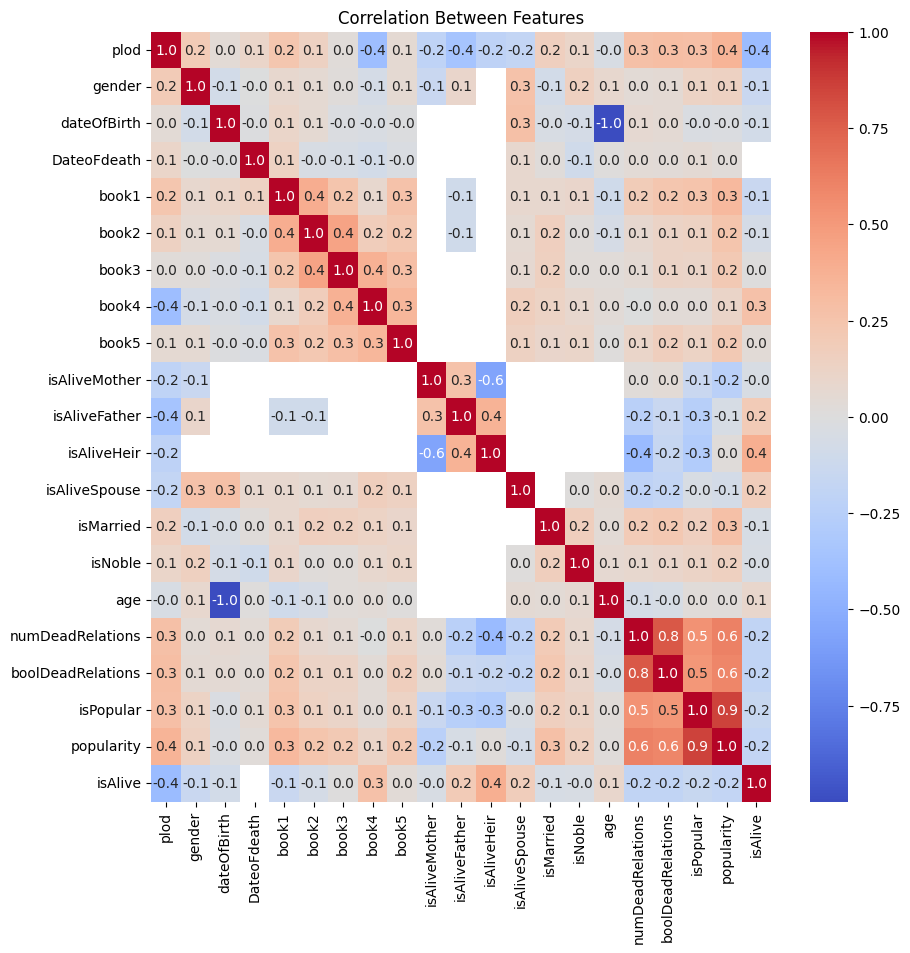

In [283]:
# Visualization of correlation between features
correlation = num_cols.corr()

plt.figure(figsize=(10, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation Between Features')

### 2.2 Univariate Analysis

#### Target Distribution 

<Axes: title={'center': 'Target Ditribution'}>

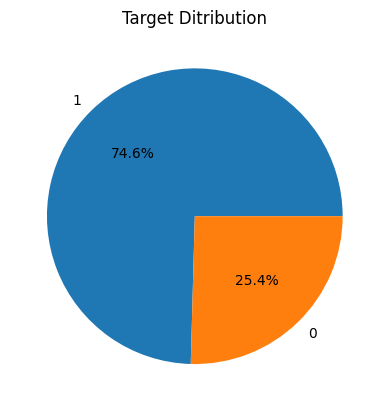

In [284]:
game['isAlive'].value_counts().plot.pie(autopct='%1.1f%%', title='Target Ditribution')

#### Range Value Distribution 

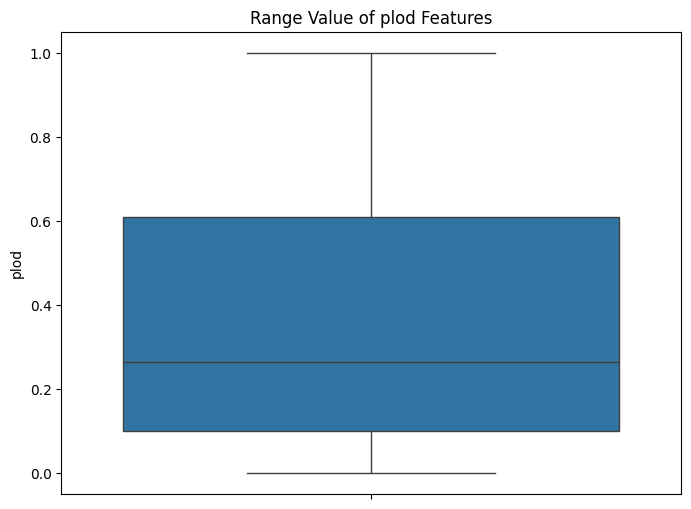

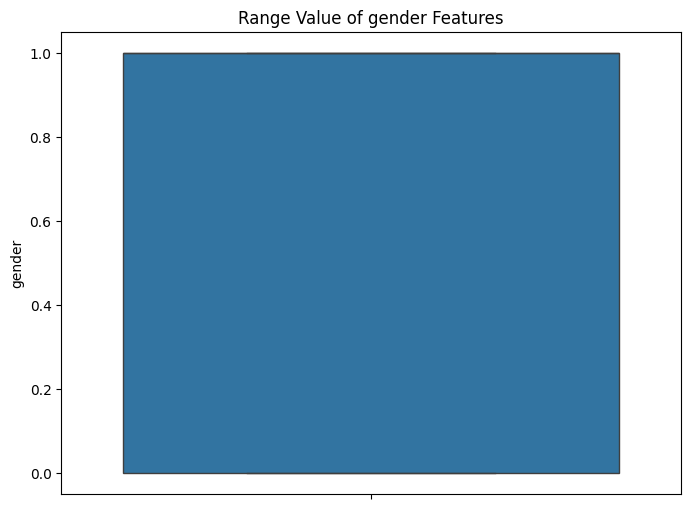

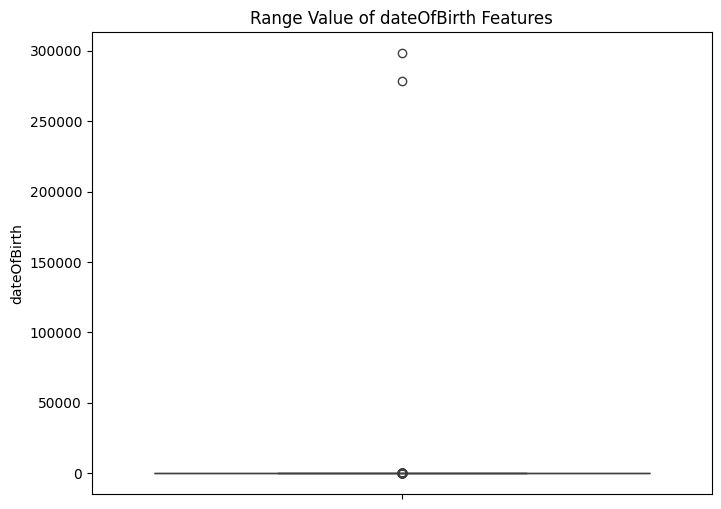

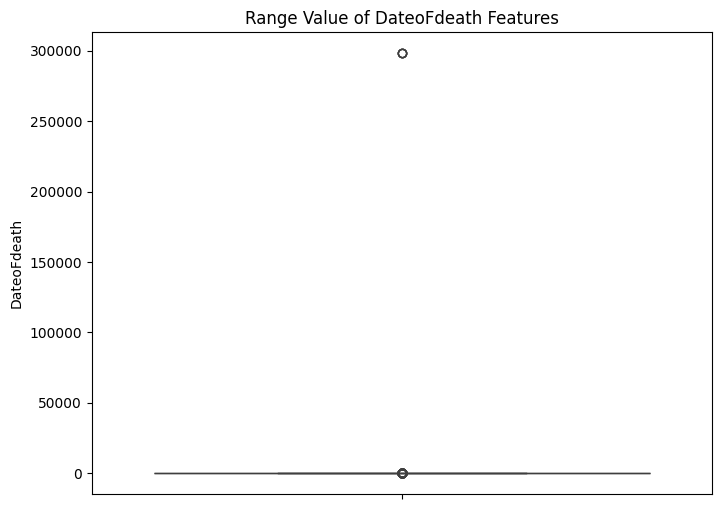

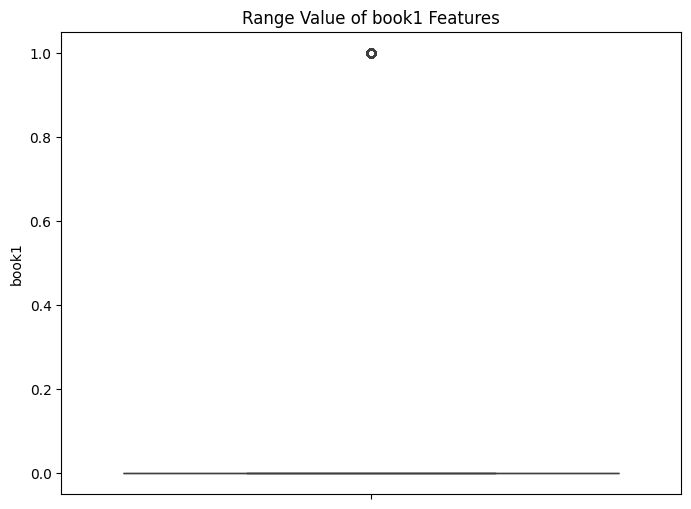

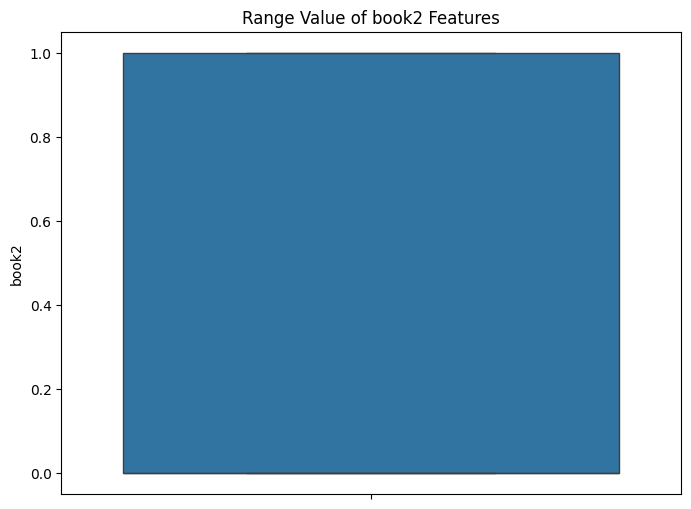

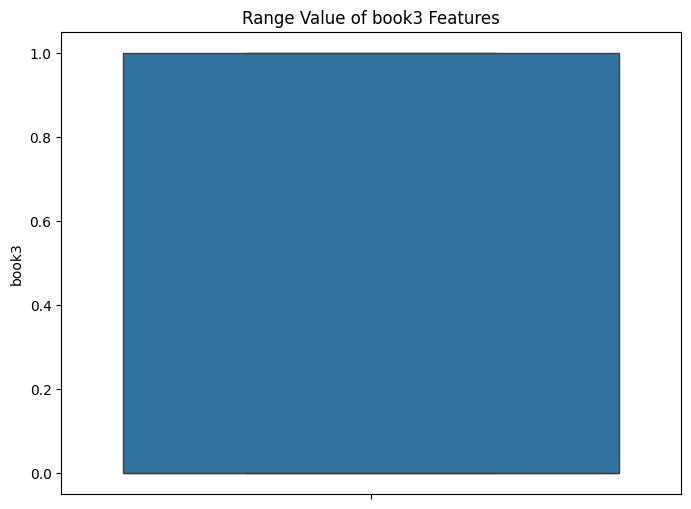

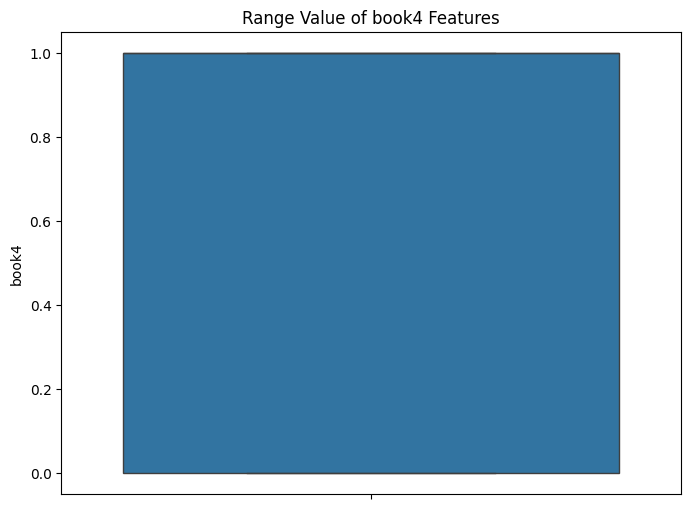

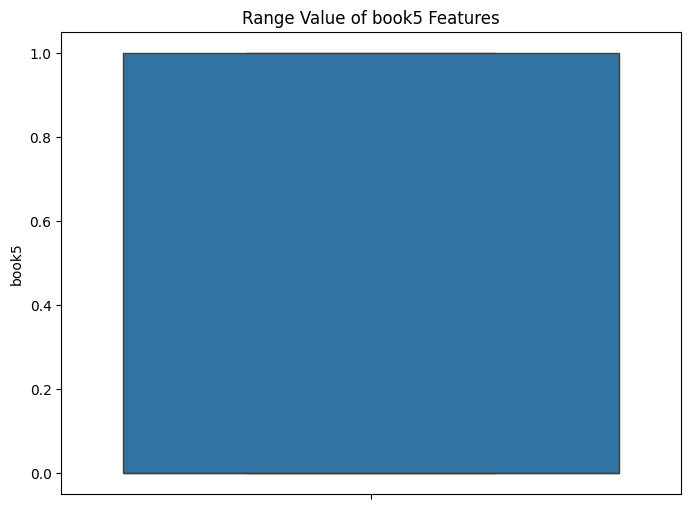

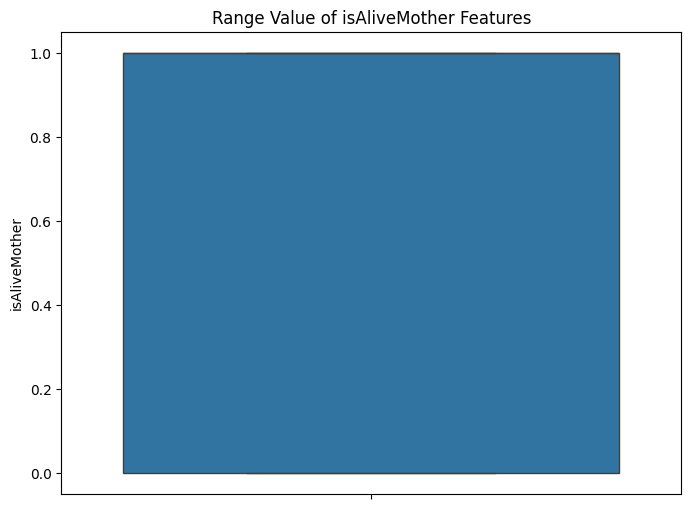

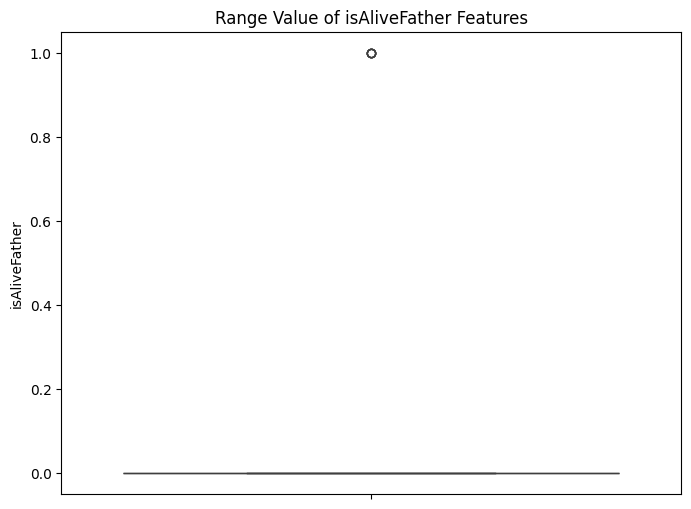

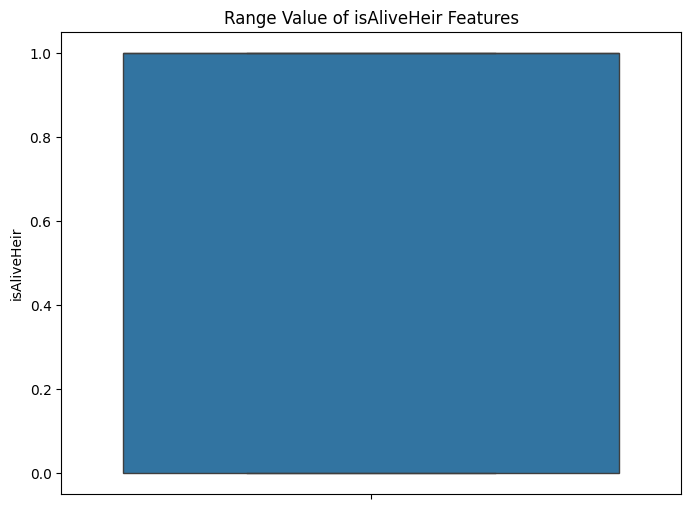

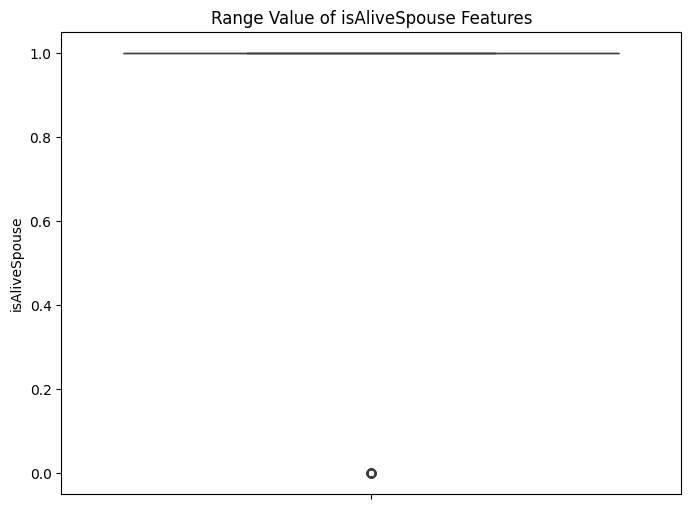

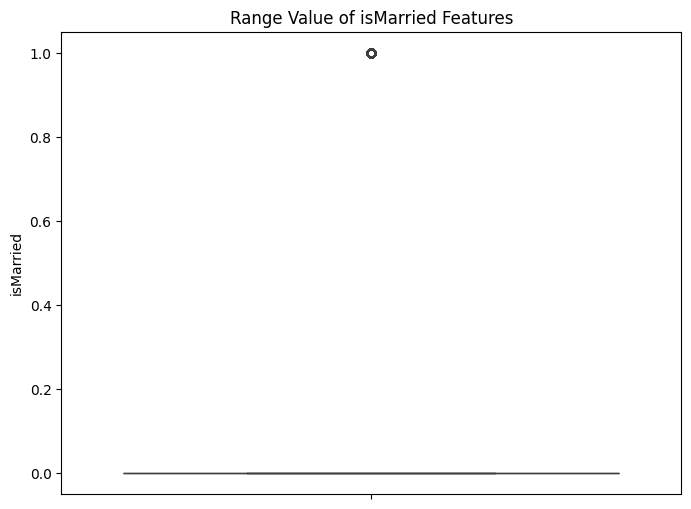

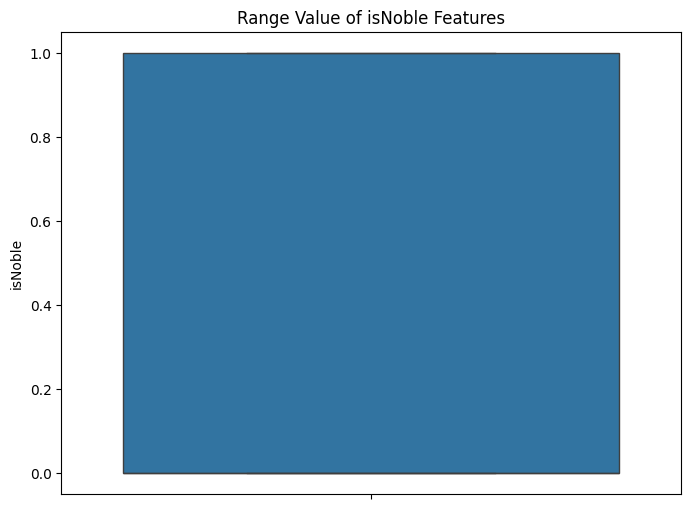

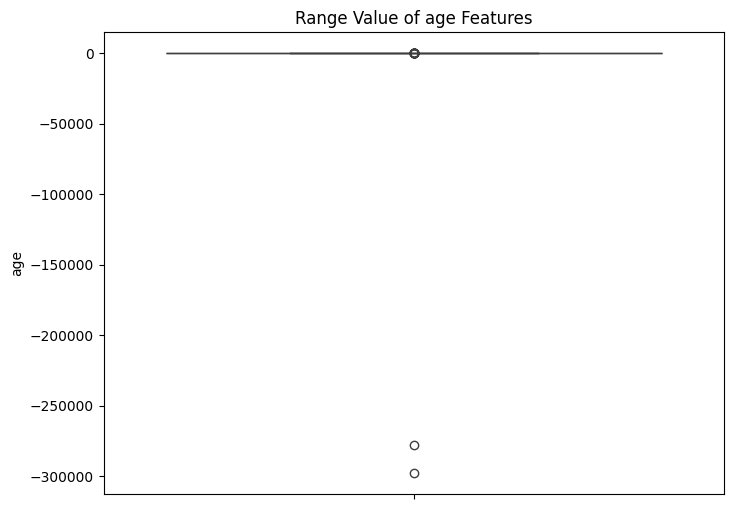

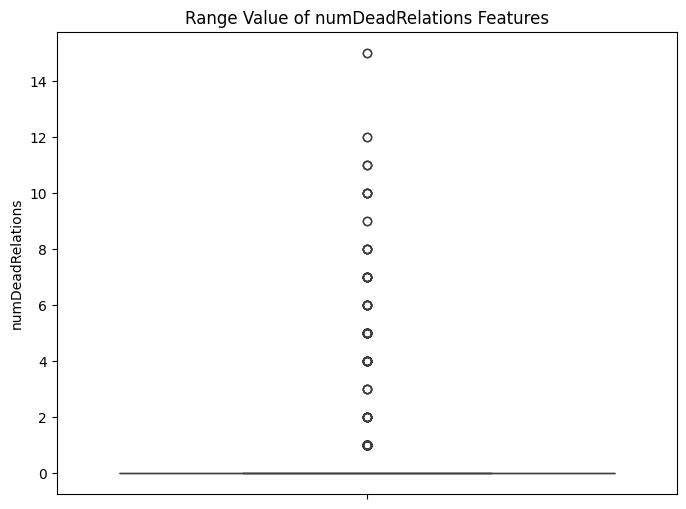

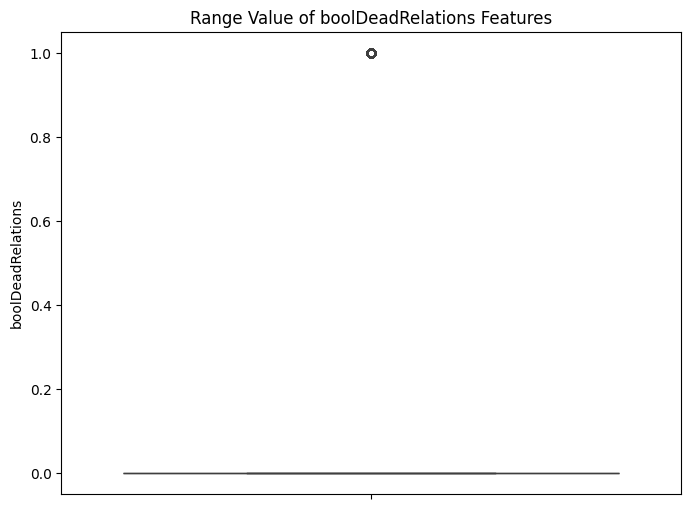

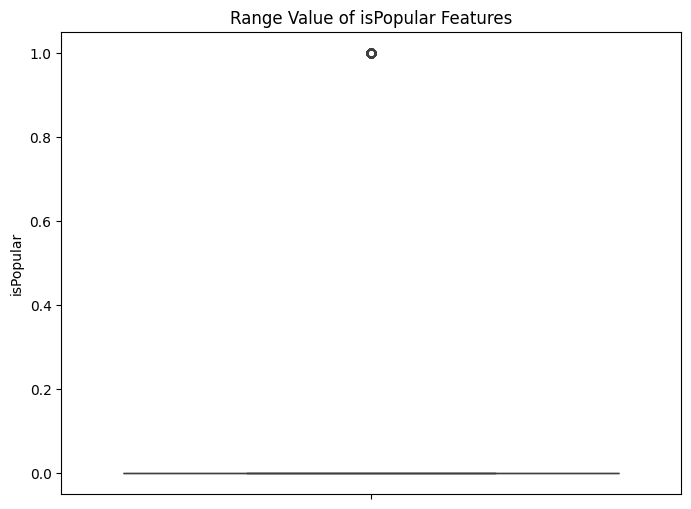

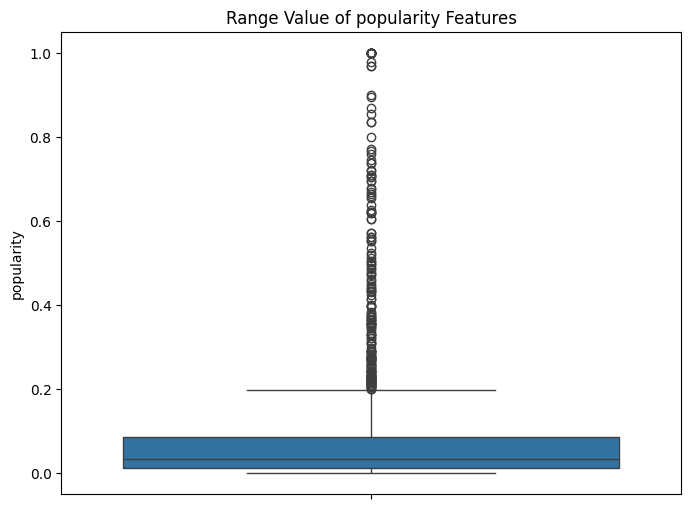

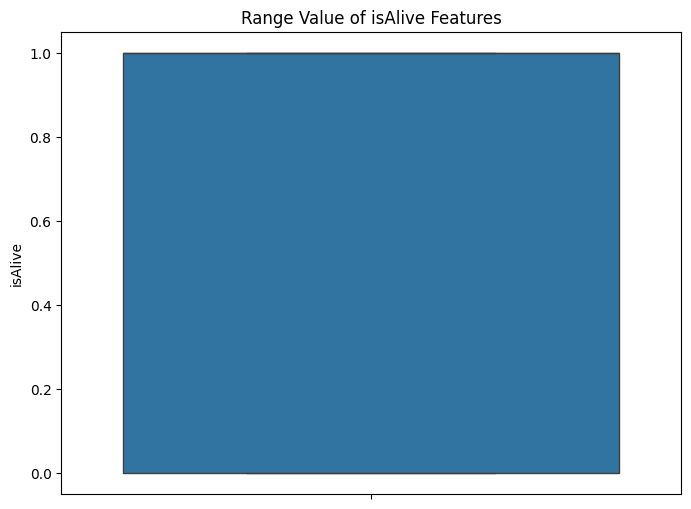

In [285]:
# Visualization of range value
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(num_cols[col])
    plt.title(f'Range Value of {col} Features')
    plt.show()

In [286]:
# Cek IQR untuk kolom Popularity
for col in num_cols:
    Q1 = game[col].quantile(0.25)
    Q3 = game[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = game[(game[col] < (Q1 - 1.5 * IQR)) | (game[col] > (Q3 + 1.5 * IQR))]
    print(f"Jumlah pencilan fitur {col}: {len(outliers)}")

Jumlah pencilan fitur plod: 0
Jumlah pencilan fitur gender: 0
Jumlah pencilan fitur dateOfBirth: 55
Jumlah pencilan fitur DateoFdeath: 100
Jumlah pencilan fitur book1: 386
Jumlah pencilan fitur book2: 0
Jumlah pencilan fitur book3: 0
Jumlah pencilan fitur book4: 0
Jumlah pencilan fitur book5: 0
Jumlah pencilan fitur isAliveMother: 0
Jumlah pencilan fitur isAliveFather: 5
Jumlah pencilan fitur isAliveHeir: 0
Jumlah pencilan fitur isAliveSpouse: 61
Jumlah pencilan fitur isMarried: 276
Jumlah pencilan fitur isNoble: 0
Jumlah pencilan fitur age: 31
Jumlah pencilan fitur numDeadRelations: 145
Jumlah pencilan fitur boolDeadRelations: 145
Jumlah pencilan fitur isPopular: 115
Jumlah pencilan fitur popularity: 197
Jumlah pencilan fitur isAlive: 0


### 2.3 Bivariate Analysis

#### Distribution per Feature vs Target

In [287]:
top_titles = game['title'].value_counts().nlargest(10).index

game['title'] = game['title'].apply(lambda x: x if x in top_titles else 'Other')
game['title'] = game['title'].fillna('Unknown')

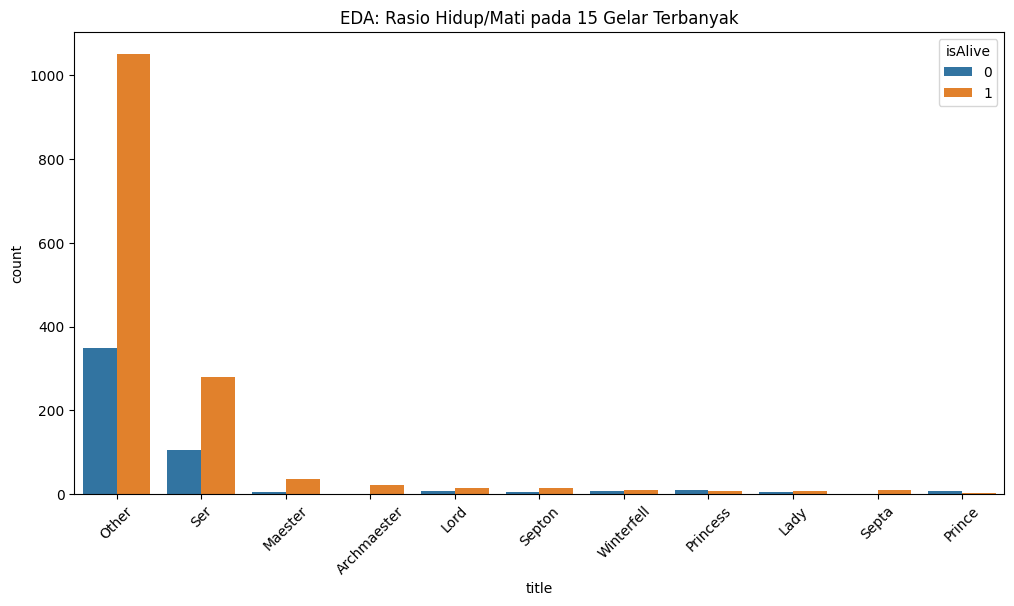

In [288]:
top_15_titles = game['title'].value_counts().head(15).index

plt.figure(figsize=(12,6))
sns.countplot(data=game[game['title'].isin(top_15_titles)], 
              x='title', 
              hue='isAlive', 
              order=top_15_titles)
plt.xticks(rotation=45)
plt.title("EDA: Rasio Hidup/Mati pada 15 Gelar Terbanyak")
plt.show()

In [289]:
num_cols.nunique()

plod                 693
gender                 2
dateOfBirth          134
DateoFdeath           69
book1                  2
book2                  2
book3                  2
book4                  2
book5                  2
isAliveMother          2
isAliveFather          2
isAliveHeir            2
isAliveSpouse          2
isMarried              2
isNoble                2
age                   85
numDeadRelations      14
boolDeadRelations      2
isPopular              2
popularity           166
isAlive                2
dtype: int64

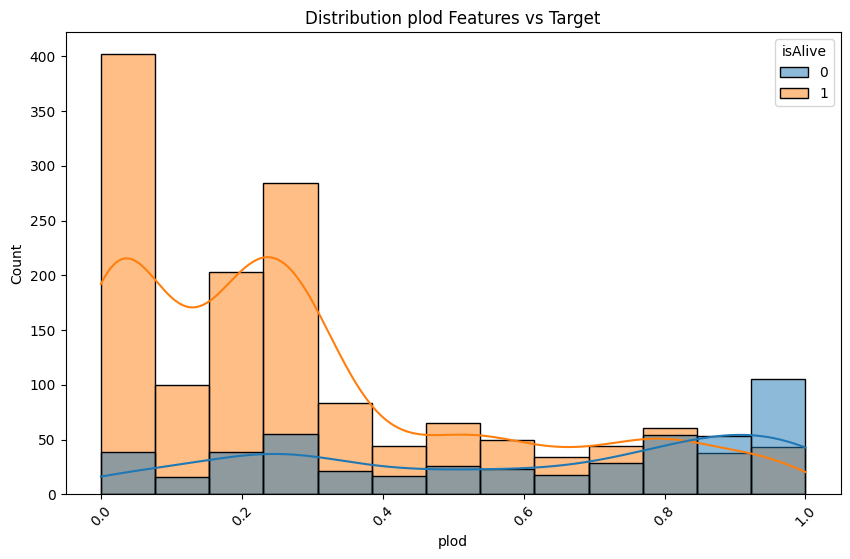

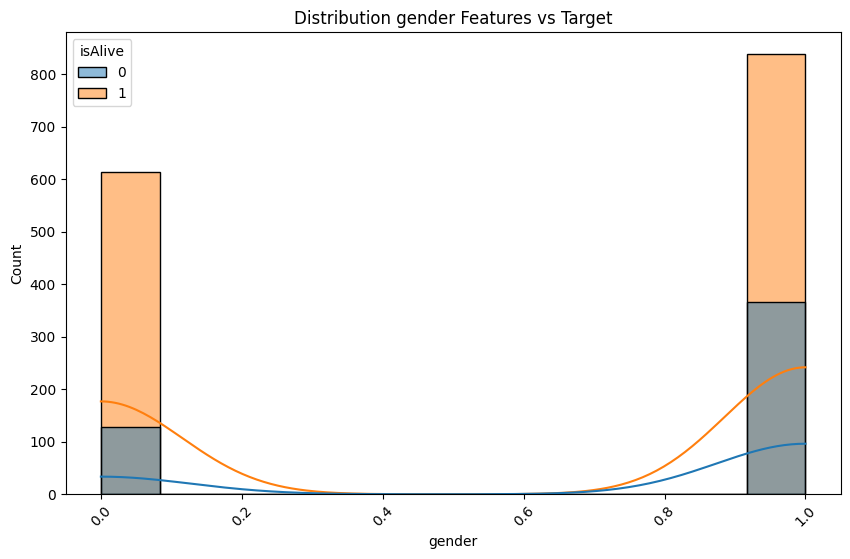

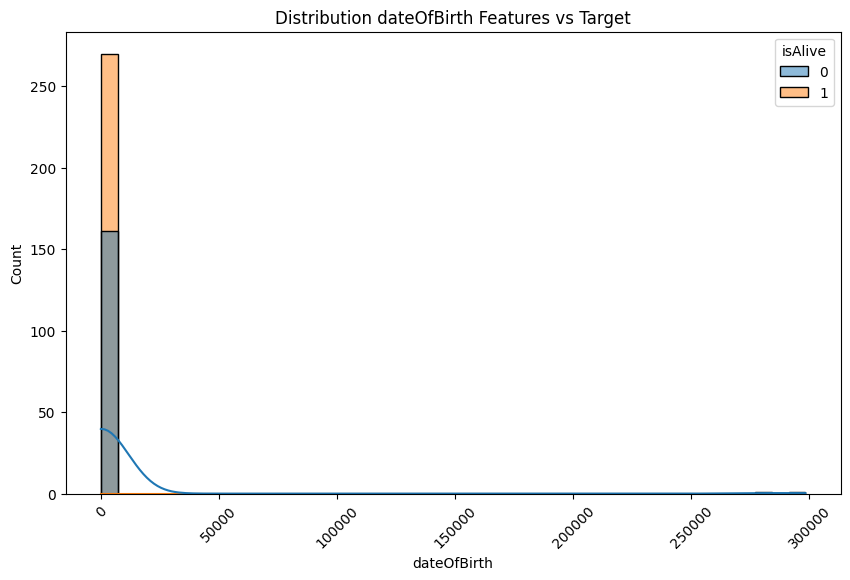

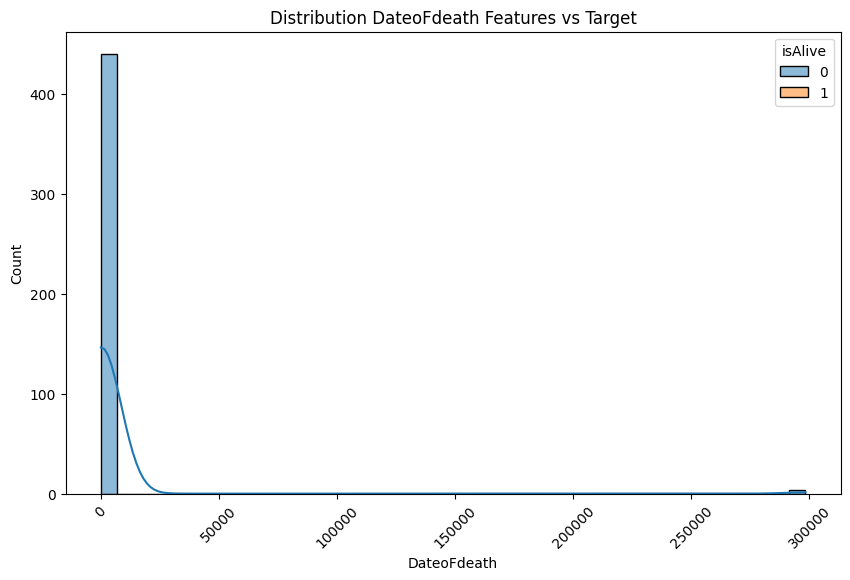

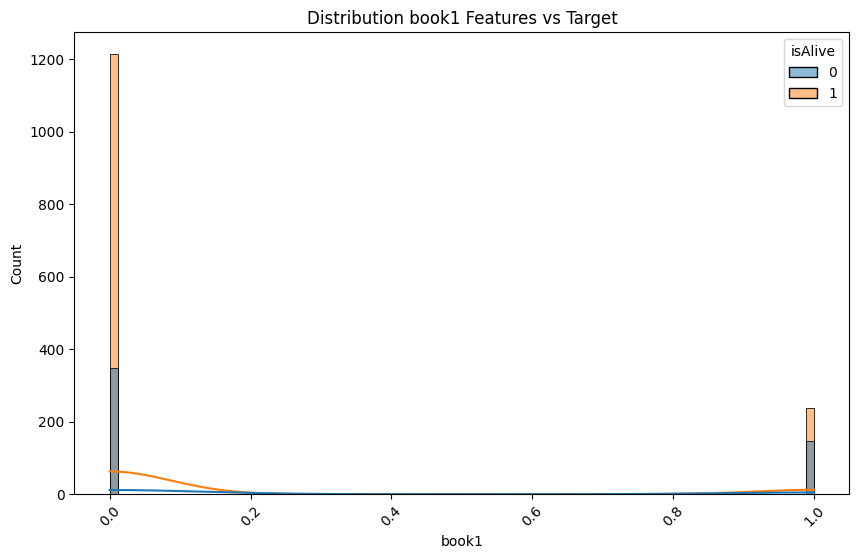

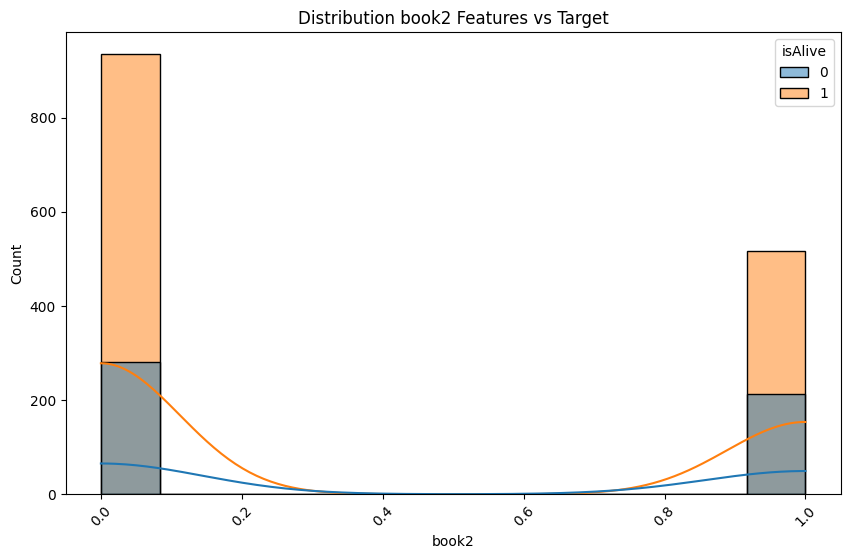

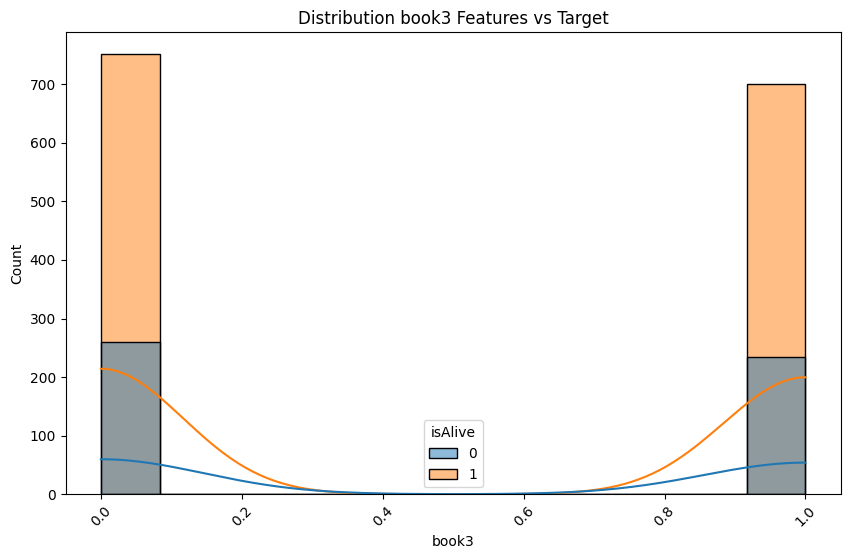

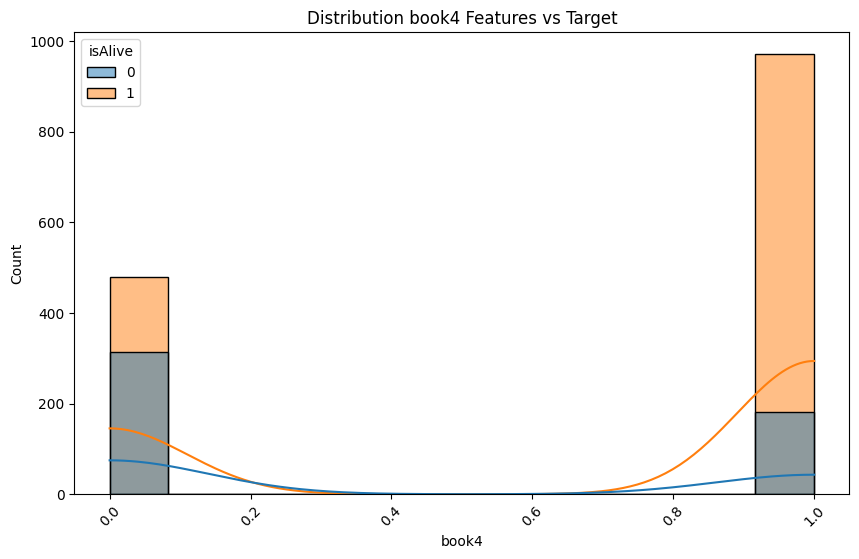

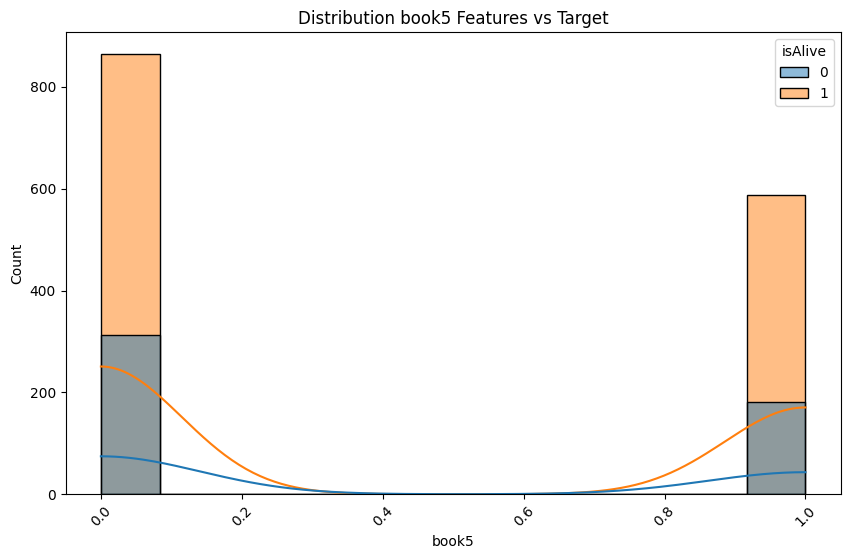

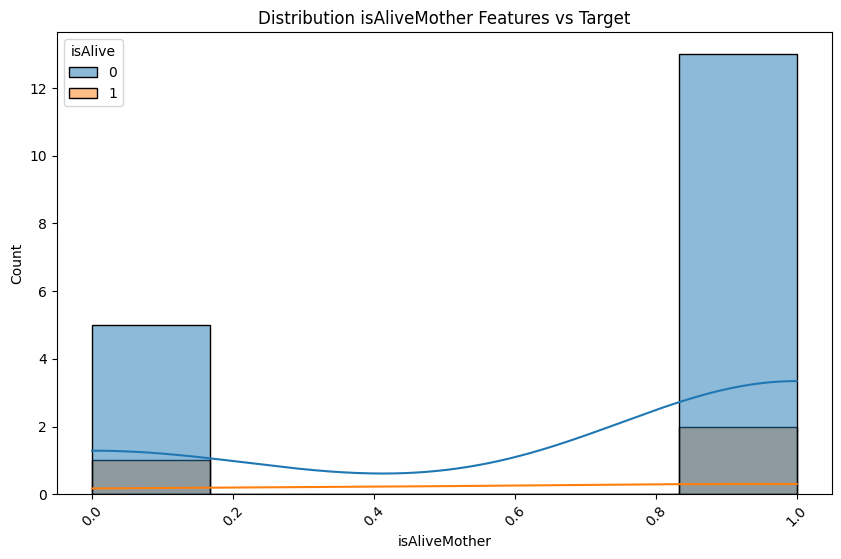

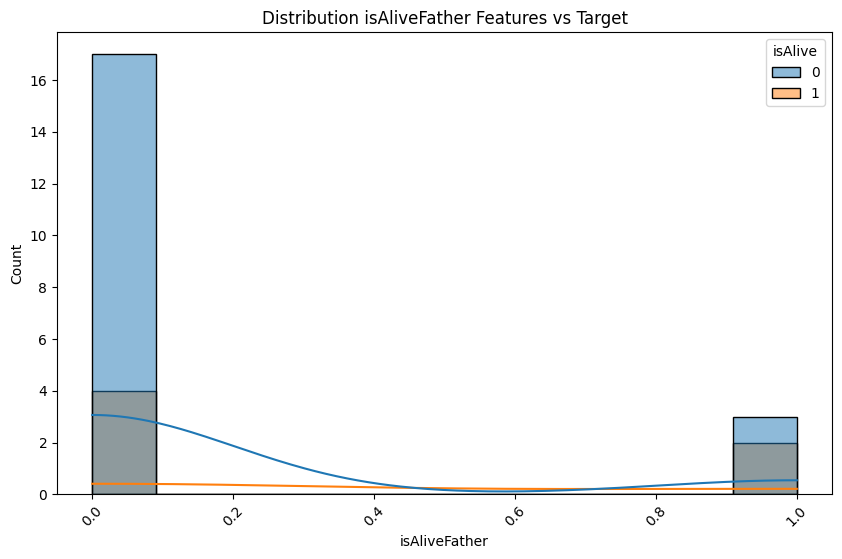

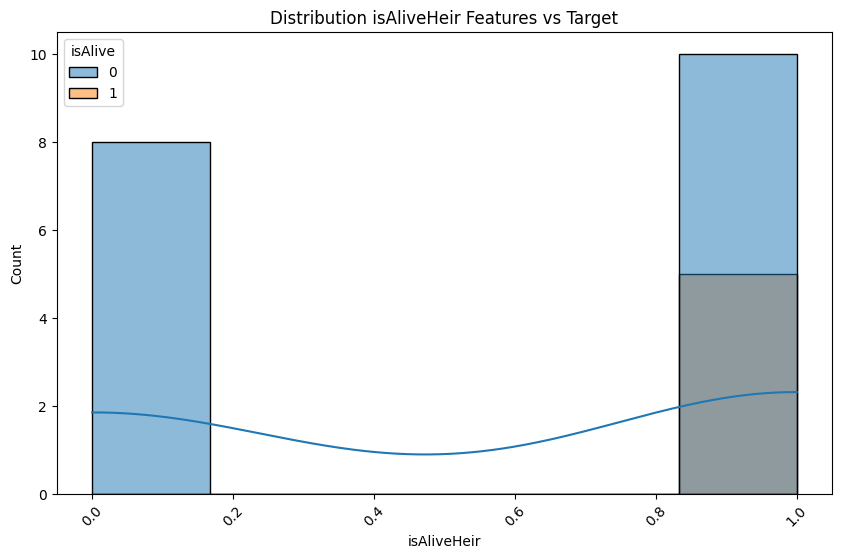

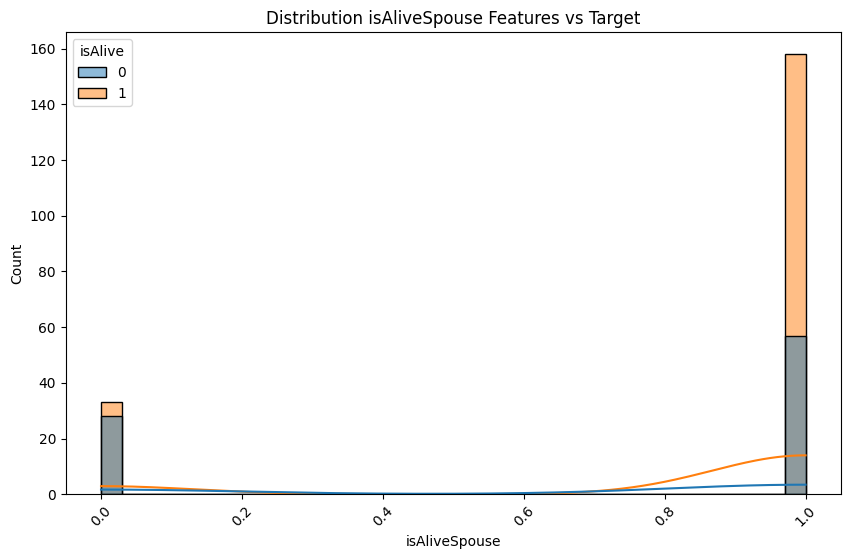

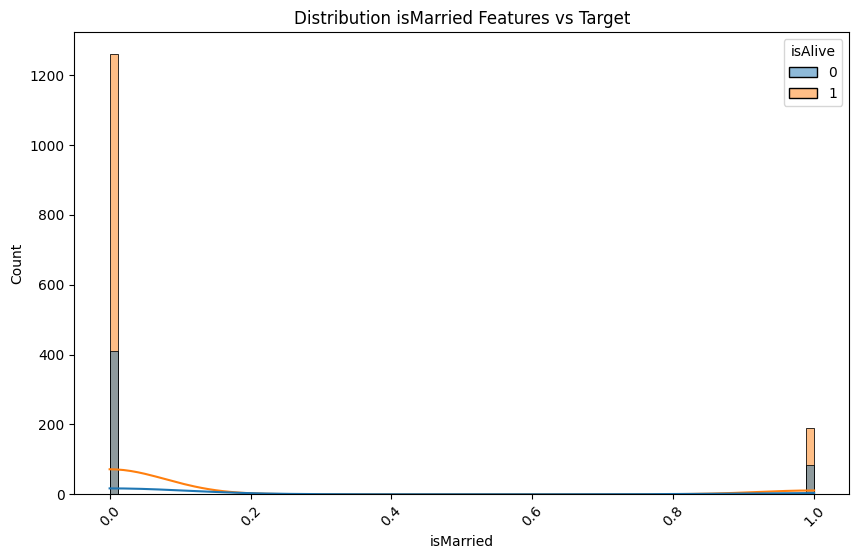

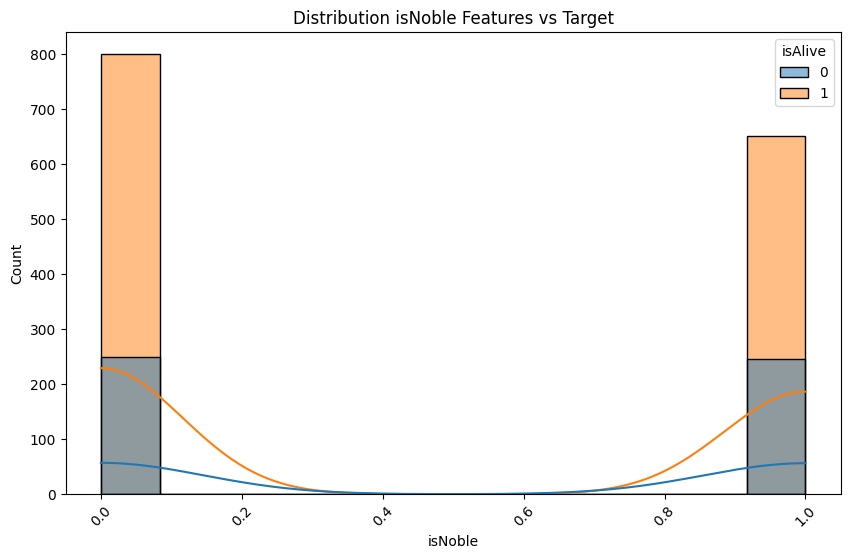

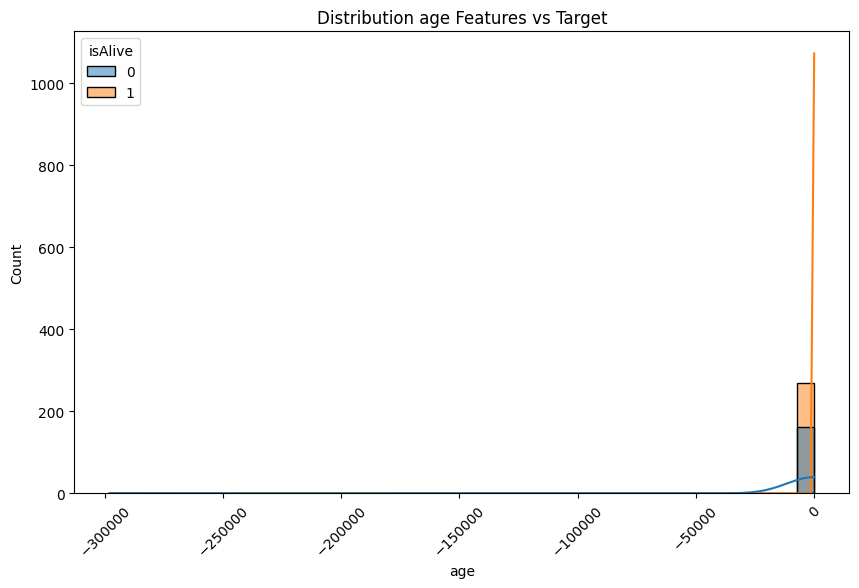

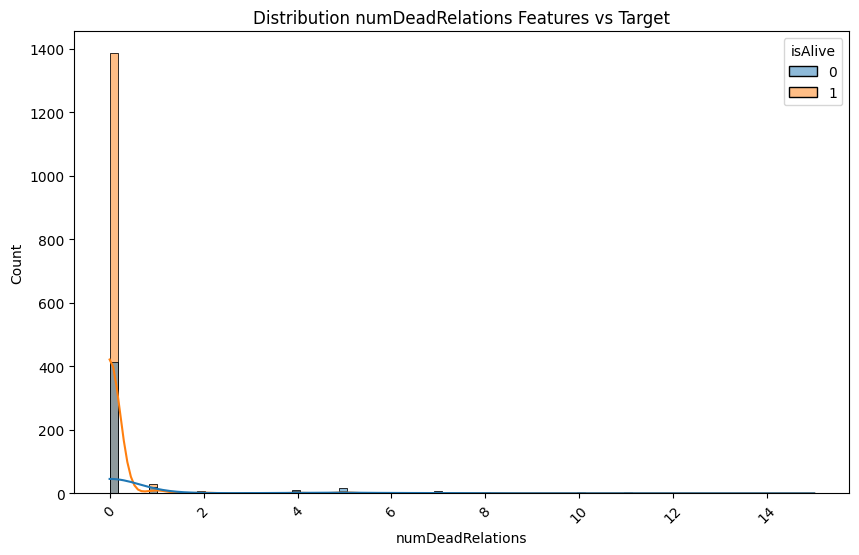

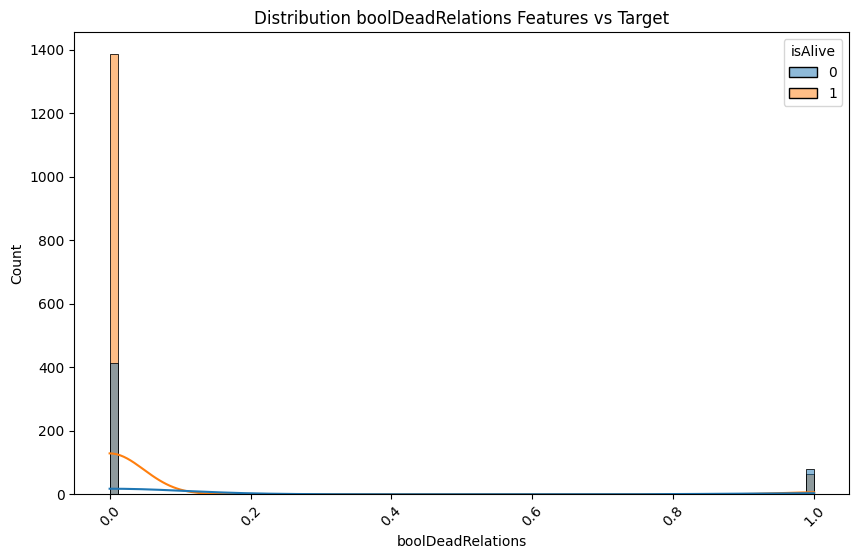

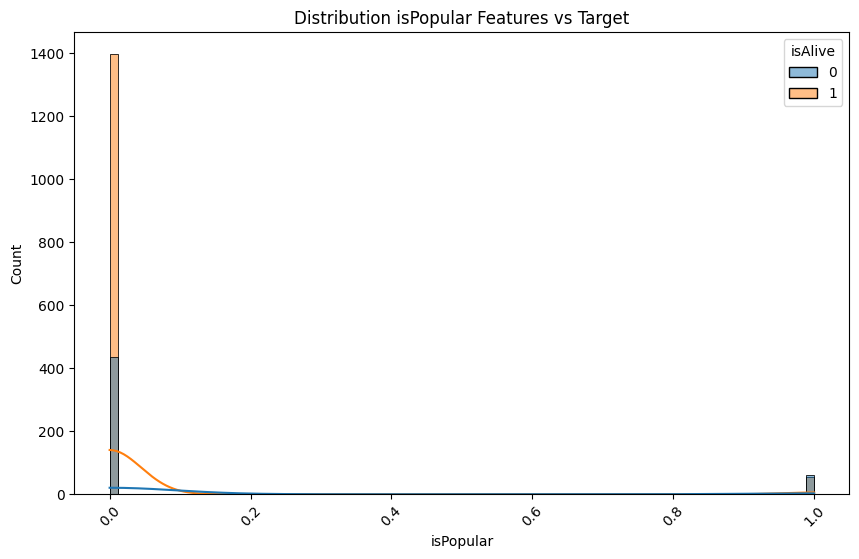

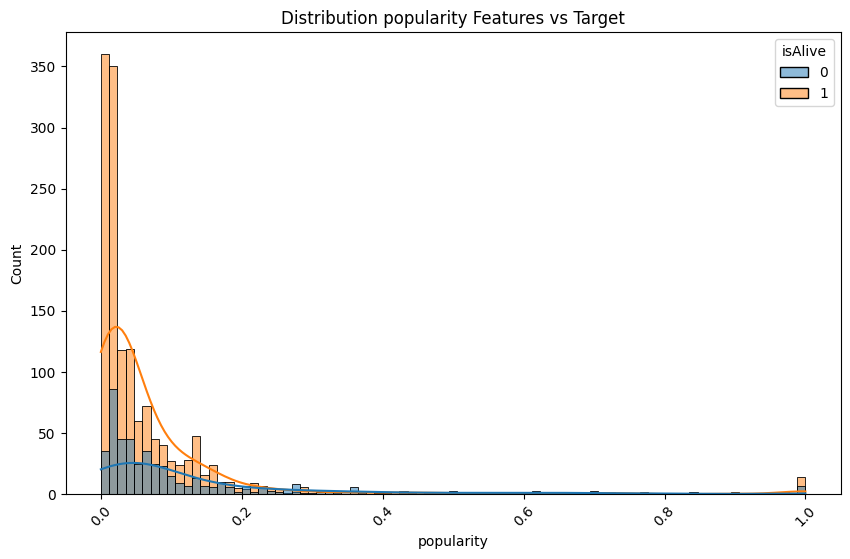

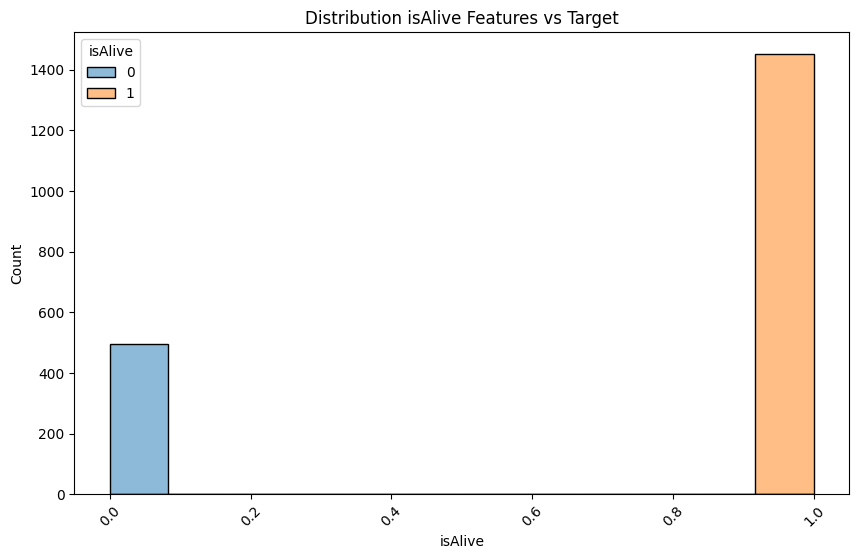

In [290]:
# Visualization of ditstirbution per Features vs Target
for col in num_cols:
    plt.figure(figsize=(10, 6))
    plt.xticks(rotation=45)
    sns.histplot(data=num_cols, x=col, hue='isAlive', kde=True)
    plt.title(f'Distribution {col} Features vs Target')
    plt.show()

## **3. Data Preprocessing**

### 3.1 Handling Missing Values

In [291]:
# Show the number of missing value
cat_cols.isnull().sum()

title      1008
culture    1269
mother     1925
father     1920
heir       1923
house       427
spouse     1670
dtype: int64

In [292]:
category_f = ['title', 'culture', 'mother', 'father', 'heir', 'house', 'spouse']
for col in category_f:
    game[col] = game[col].fillna('Unknown')

game.isnull().sum()

plod                    0
title                   0
gender                  0
culture                 0
dateOfBirth          1513
DateoFdeath          1502
mother                  0
father                  0
heir                    0
house                   0
spouse                  0
book1                   0
book2                   0
book3                   0
book4                   0
book5                   0
isAliveMother        1925
isAliveFather        1920
isAliveHeir          1923
isAliveSpouse        1670
isMarried               0
isNoble                 0
age                  1513
numDeadRelations        0
boolDeadRelations       0
isPopular               0
popularity              0
isAlive                 0
dtype: int64

In [293]:
num_cols.nunique()

plod                 693
gender                 2
dateOfBirth          134
DateoFdeath           69
book1                  2
book2                  2
book3                  2
book4                  2
book5                  2
isAliveMother          2
isAliveFather          2
isAliveHeir            2
isAliveSpouse          2
isMarried              2
isNoble                2
age                   85
numDeadRelations      14
boolDeadRelations      2
isPopular              2
popularity           166
isAlive                2
dtype: int64

In [294]:
# def unique_values(features):
#     print(f'Fitur: {features}')
#     print('Number of unique values:', game[features].nunique())
#     print('Unique Values:', game[features].unique())

# unique_values('age')

In [295]:
# Separate features 
ordinal_f = ['gender', 'book1', 'book2', 'book3', 'book4', 'book5', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse', 'isMarried', 'isNoble', 'boolDeadRelations', 'isPopular', 'isAlive']
continue_f = ['plod', 'dateOfBirth', 'DateoFdeath', 'age', 'numDeadRelations', 'popularity']
game[continue_f].isnull().sum()

plod                   0
dateOfBirth         1513
DateoFdeath         1502
age                 1513
numDeadRelations       0
popularity             0
dtype: int64

In [296]:
input_features = [f for f in ordinal_f if f != 'isAlive']

# Isi dengan -1 untuk menandakan "Unknown"
for col in input_features:
    game[col] = game[col].fillna(-1)

In [297]:
game['age'] = game['age'].fillna(game['age'].median())

In [298]:
# Drop 'dateOfBirth' and 'DateoFdeath' fetures 
features = ['DateoFdeath', 'dateOfBirth']
game = game.drop(features, axis=1)

In [299]:

# Show the number of missing value
game.isnull().sum().sum()

np.int64(0)

### 3.2 Encode Categrical Features

In [300]:
# Show number of unique values
game[category_f].nunique()

title       11
culture     65
mother      18
father      21
heir        23
house      348
spouse     255
dtype: int64

In [301]:
# Daftar kolom dari gambar Anda
cols_to_encode = ['title', 'culture', 'mother', 'father', 'heir', 'house', 'spouse']

for col in cols_to_encode:
    game[col], _ = pd.factorize(game[col])

In [302]:
# show information of dataset
game.info()

<class 'pandas.DataFrame'>
RangeIndex: 1946 entries, 0 to 1945
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plod               1946 non-null   float64
 1   title              1946 non-null   int64  
 2   gender             1946 non-null   int64  
 3   culture            1946 non-null   int64  
 4   mother             1946 non-null   int64  
 5   father             1946 non-null   int64  
 6   heir               1946 non-null   int64  
 7   house              1946 non-null   int64  
 8   spouse             1946 non-null   int64  
 9   book1              1946 non-null   int64  
 10  book2              1946 non-null   int64  
 11  book3              1946 non-null   int64  
 12  book4              1946 non-null   int64  
 13  book5              1946 non-null   int64  
 14  isAliveMother      1946 non-null   float64
 15  isAliveFather      1946 non-null   float64
 16  isAliveHeir        1946 non-null   

### 3.3 Independent and Dependent Variable 


In [303]:
X = game.drop(['isAlive', 'plod'], axis=1)
y = game['isAlive']

## **4. Model** 

### 4.1 Split Data

In [304]:
def split_data(X, y, size=0.8):
    np.random.seed(42)

    X_train, X_test = [], []
    y_train, y_test = [], []

    for classes in np.unique(y):
        class_idx = np.where(y == classes)[0]
        idx = np.random.permutation(len(class_idx))
        split = int(len(class_idx) * size)

        X_train.append(X.iloc[idx[:split]])
        X_test.append(X.iloc[idx[split:]])
        y_train.append(y.iloc[idx[:split]])
        y_test.append(y.iloc[idx[split:]])

    X_train = pd.concat(X_train).reset_index(drop=True)
    X_test = pd.concat(X_test).reset_index(drop=True)
    y_train = pd.concat(y_train).reset_index(drop=True)
    y_test = pd.concat(y_test).reset_index(drop=True)

    return X_train, X_test, y_train, y_test

### 4.2 Inisialisasi Split Data

In [305]:
X_train, X_test, y_train, y_test = split_data(X, y)

for val in [X_train, X_test, y_train, y_test]:
    print(val.shape)

(1556, 24)
(390, 24)
(1556,)
(390,)


### 4.3 Decision Tree CART 

In [306]:
class Node:
    def __init__(self, gini=0, num_samples=0, num_samples_per_class=None, predicted_class=None, feature_index=None, threshold=None, left=None, right=None):
        self.gini = gini
        self.num_samples = num_samples
        self.num_samples_per_class = num_samples_per_class
        self.predicted_class = predicted_class
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right

class DTCART:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.tree_ = None
        self.classes_ = None
        self.n_classes_ = None
        self.n_features_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).ravel()

        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        self.n_features_ = X.shape[1]

        class_to_idx = {cls: idx for idx, cls in enumerate(self.classes_)}
        y_indexed = np.array([class_to_idx[cls] for cls in y], dtype=int)

        self.tree_ = self._grow_tree(X, y_indexed, depth=0)
        return self

    def _gini(self, y):
        m = len(y)
        if m == 0:
            return 0.0
        
        counts = np.bincount(y, minlength=self.n_classes_)
        probs = counts / m

        return 1.0 - np.sum(probs ** 2)

    def _best_split(self, X, y):
        m, n = X.shape
        if m <= 1:
            return None, None

        parent_gini = self._gini(y)
        best_gini = parent_gini + 1
        best_idx, best_thr = None, None

        for feature_idx in range(n):
            sorted_indices = np.argsort(X[:, feature_idx])
            X_sorted = X[sorted_indices, feature_idx]
            y_sorted = y[sorted_indices]

            num_left = np.zeros(self.n_classes_, dtype=int)
            num_right = np.bincount(y_sorted, minlength=self.n_classes_)

            for i in range(1, m):
                c = y_sorted[i - 1]
                num_left[c] += 1
                num_right[c] -= 1

                if X_sorted[i] == X_sorted[i - 1]:
                    continue

                n_left = i
                n_right = m - i

                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                gini_left = 1.0 - np.sum((num_left / n_left) ** 2)
                gini_right = 1.0 - np.sum((num_right / n_right) ** 2)

                gini = (n_left * gini_left + n_right * gini_right) / m

                if gini < best_gini:
                    best_gini = gini
                    best_idx = feature_idx
                    best_thr = (X_sorted[i] + X_sorted[i - 1]) / 2
        return best_idx, best_thr

    
    def _grow_tree(self, X, y, depth=0):
        num_samples_per_class = np.bincount(y, minlength=self.n_classes_)
        predicted_class = np.argmax(num_samples_per_class)

        node = Node(
            gini = self._gini(y),
            num_samples = len(y),
            num_samples_per_class=num_samples_per_class,
            predicted_class=predicted_class

        )

        if (self.max_depth is not None and depth >= self.max_depth) or \
           len(y) < self.min_samples_split or \
           len(np.unique(y)) == 1:
            return node
        
        feature_idx, threshold  = self._best_split(X, y)

        if feature_idx is None:
            return node

        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask

        if np.sum(left_mask) < self.min_samples_leaf or \
           np.sum(right_mask) < self.min_samples_leaf:
            return node
            
        node.feature_index = feature_idx
        node.threshold = threshold

        node.left = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
        node.right = self._grow_tree(X[right_mask], y[right_mask], depth + 1)

        return node


    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_sample(x) for x in X])

    def _predict_sample(self, x):
        node = self.tree_
        while node.left is not None and node.right is not None:
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return self.classes_[node.predicted_class]

    def predict_proba(self, X):
        X = np.asarray(X)
        return np.array([self._predict_proba_sample(x) for x in X])

    def _predict_proba_sample(self, x):
        node = self.tree_
        while node.left is not None and node.right is not None:
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right

        probs = node.num_samples_per_class / node.num_samples
        return probs

    def score(self, X, y):
        y = np.asarray(y).ravel()
        predictions = self.predict(X)
        return np.mean(predictions == y)

    def print_tree(self, node=None, indent=''):
        if node is None:
            node = self.tree_

        info = f'Gini {node.gini} - Sample {node.num_samples} - '
        info += f'Class {self.classes_[node.predicted_class]}'

        if node.left is None and node.right is None:
            print(indent + 'leaf: ' + info)
        else:
            feature_name = f'Feature {node.feature_index}'
            print(indent + f'Split {feature_name} <= {node.threshold}' + info)
            print(indent + 'left')
            self.print_tree(node.left, indent + ' ')
            print(indent + 'right')
            self.print_tree(node.right, indent + ' ')
        

### 4.4 Resampling Smote

In [307]:
# using SMOTE technique
def SMOTE(X, y, k=5):
    np.random.seed(42)

    counts = y.value_counts()
    minority_class = counts.idxmin()

    X_np = X.values
    y_np = y.values

    minority_X = X_np[y_np == minority_class]
    n_synthethic = counts.max() - counts.min()

    synthethic_samples = []

    for _ in range(n_synthethic):
        idx = np.random.randint(0, len(minority_X))
        sample = minority_X[idx]

        distances = np.sqrt(np.sum((minority_X - sample)**2, axis=1))
        nn_indicies = np.argsort(distances)[1:k+1]
        nn_idx = np.random.choice(nn_indicies)
        neighboor = minority_X[nn_idx]

        gap = np.random.rand()
        synthethic_samples.append(sample + gap * (neighboor - sample))

    X_balanced = np.vstack((X_np, synthethic_samples))
    y_balanced = np.hstack((y_np, np.full(n_synthethic, minority_class)))
    shuffle_idx = np.random.permutation(len(y_balanced))
    
    X_smote = pd.DataFrame(X_balanced[shuffle_idx], columns=X.columns)
    y_smote = pd.Series(y_balanced[shuffle_idx], name=y.name)
    
    return X_smote, y_smote

In [308]:
X_train_smote, y_train_smote = SMOTE(X_train, y_train)

### 4.5 Grid Search

In [309]:
best_depth = None
best_acc = 0
accuracy = []

for depth in [2,3,4,5,6,7,8,9,10,11]:
    model = DTCART(max_depth=depth)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = np.mean(pred == y_test)
    # model.print_tree() 

    print(f'Depth: {depth} - Accuracy: {acc:.4f}')

    if acc > best_acc:
        best_acc = acc
        best_depth = depth
print(f'Best Depth: {best_depth} - Accuracy: {best_acc:.4f}')

Depth: 2 - Accuracy: 0.8231
Depth: 3 - Accuracy: 0.8179
Depth: 4 - Accuracy: 0.8282
Depth: 5 - Accuracy: 0.8256
Depth: 6 - Accuracy: 0.8359
Depth: 7 - Accuracy: 0.8410
Depth: 8 - Accuracy: 0.8538
Depth: 9 - Accuracy: 0.8538
Depth: 10 - Accuracy: 0.8590
Depth: 11 - Accuracy: 0.8385
Best Depth: 10 - Accuracy: 0.8590


### 4.6 Inisialisasi Model

In [310]:
model = DTCART(max_depth=best_depth)
model.fit(X_train, y_train)

model_smote = DTCART(max_depth=best_depth)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

y_pred_train_smote = model_smote.predict(X_train_smote)
y_pred_test_smote = model_smote.predict(X_test)

## **5. Evaluasi**

### 5.1 Fungsi Evaluasi

In [311]:
def evaluate(y_true, y_pred, title='Train'):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    classes = np.unique(y_true)

    accuracy = []
    precision = []
    recall = []
    f1 = []

    for i in classes:
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        precision.append(p)
        recall.append(r)
        f1.append(f)

    accuracy = np.mean(y_true == y_pred)
    precision = np.mean(precision)
    recall = np.mean(recall)
    f1 = np.mean(f1)

    print(f'\nEvaluasi Data {title}')
    print(f'Accuracy    : {accuracy:.4%}')
    print(f'Precision   : {precision:.4%}')
    print(f'Recall      : {recall:.4%}')
    print(f'F1          : {f1:.4%}')

### 5.2 Inisialisasi Fungsi Evaluasi

#### 5.2.1 Hasil Evaluasi

In [312]:
evaluate(y_train, y_pred_train)
evaluate(y_test, y_pred_test, title='Test')


Evaluasi Data Train
Accuracy    : 90.3599%
Precision   : 93.0132%
Recall      : 78.9263%
F1          : 83.4834%

Evaluasi Data Test
Accuracy    : 85.8974%
Precision   : 78.3243%
Recall      : 71.6345%
F1          : 74.1351%


#### 5.2.2 Hasil Evaluasi Data Smote

In [313]:
evaluate(y_train_smote, y_pred_train_smote)
evaluate(y_test, y_pred_test_smote, title='Test')


Evaluasi Data Train
Accuracy    : 93.3581%
Precision   : 93.3647%
Recall      : 93.3581%
F1          : 93.3578%

Evaluasi Data Test
Accuracy    : 81.2821%
Precision   : 69.7336%
Recall      : 70.3387%
F1          : 70.0250%


### 5.3 Fungsi Confusion Matrix

In [314]:
def confusion_matrix(y_true, y_pred, title='Train'):
    classes = np.unique(y_true)
    n_classes = len(classes)

    cm = np.zeros((n_classes, n_classes))

    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm[i, j] = np.sum((y_true == c_true) * (y_pred == c_pred))
    
    plt.figure(figsize=(10,8))
    plt.title(f'Confusion Matrix data {title}')
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=False)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

### 5.4 Inisialisasi Fungsi Confusion Matrix

#### 5.4.1 Confusion Matrix 

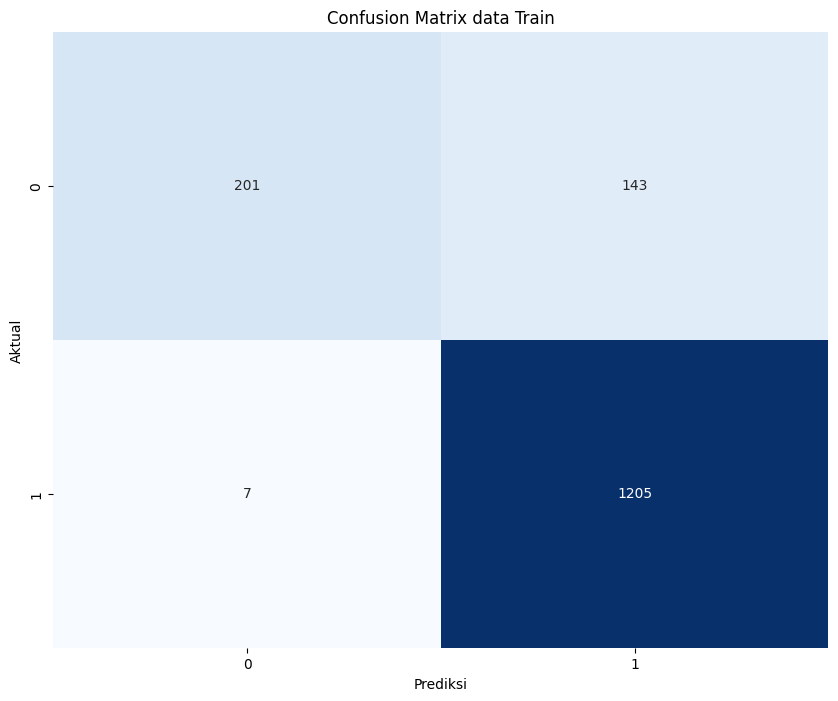

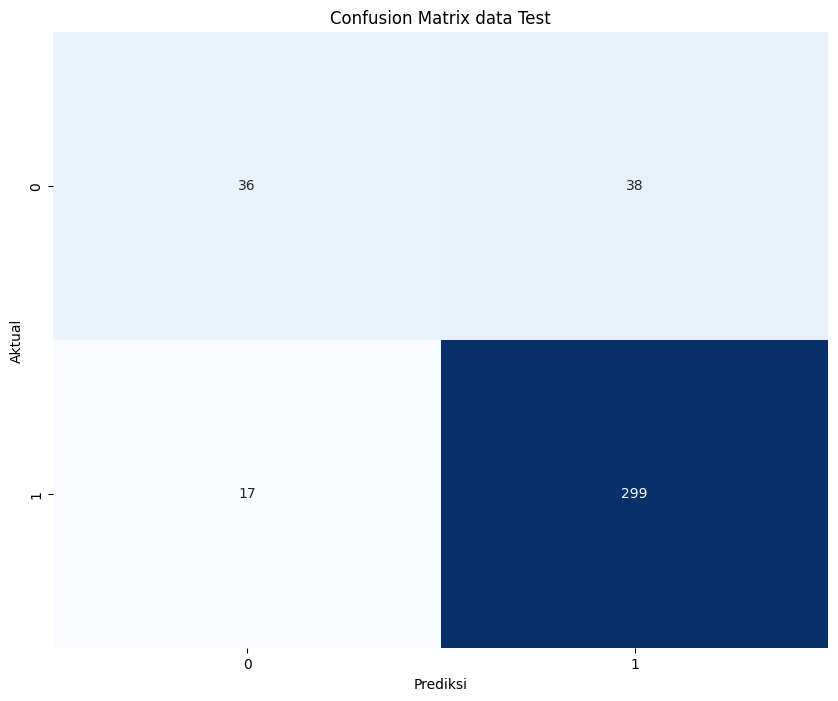

In [315]:
confusion_matrix(y_train, y_pred_train)
confusion_matrix(y_test, y_pred_test, title='Test')

#### 5.4.2 Confusion Matrix Data Smote


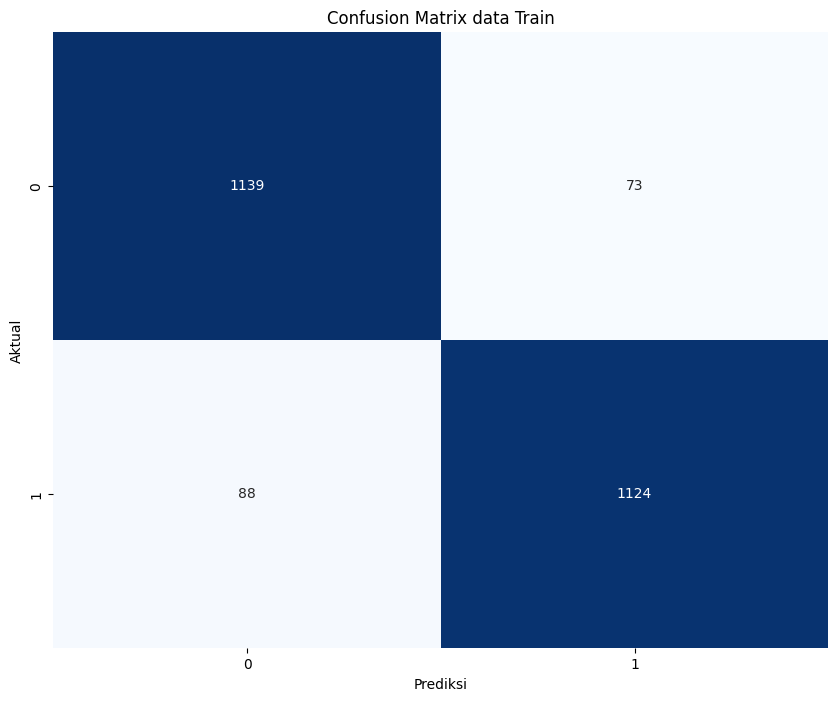

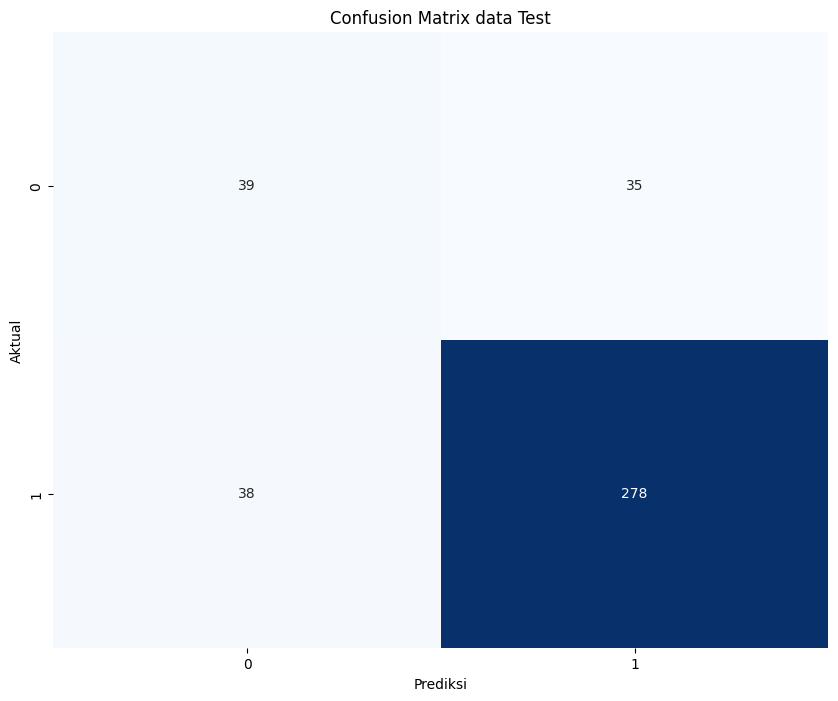

In [316]:
confusion_matrix(y_train_smote, y_pred_train_smote)
confusion_matrix(y_test, y_pred_test_smote, title='Test')

### 5.5 Decision Tree Plot

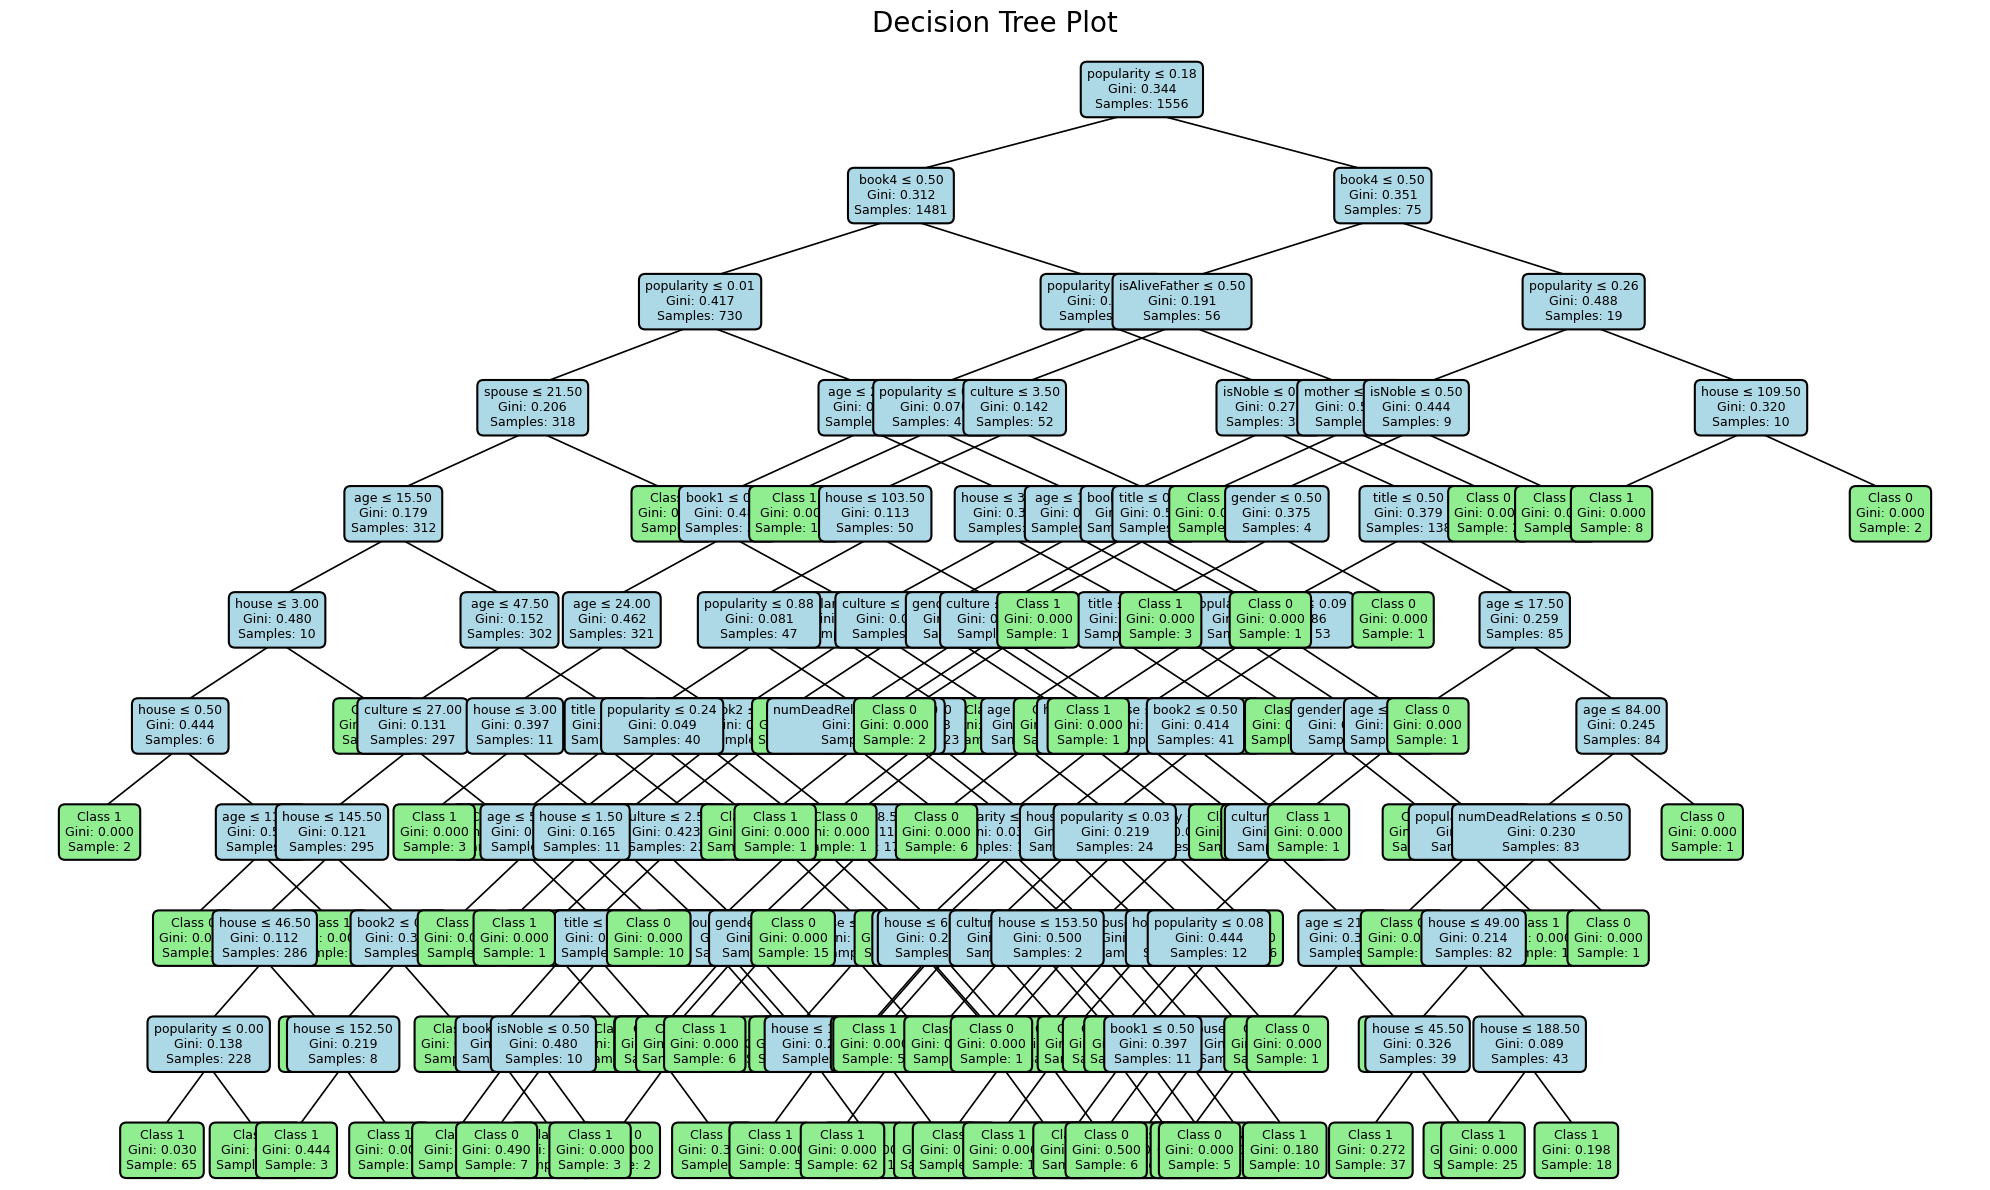

In [317]:
def visualize_tree(tree, feature_name, depth=0, x=0.5, y=1.0, dx=0.3, parent_x=None):
    box_props = dict(
        boxstyle='round,pad=0.5',
        facecolor='lightgreen' if (isinstance(tree, str) or 
                                   (not isinstance(tree, dict) and tree.left is None and tree.right is None)) 
                  else 'lightblue',
        edgecolor='black',
        linewidth=1.5
    )
    
    if isinstance(tree, str):
        plt.text(x, y, tree, ha='center', va='center', fontsize=9, 
                bbox=box_props, zorder=3)
        return

    if isinstance(tree, dict):
        feature_idx = tree['feature_idx']
        val = tree['val']
        left = tree['left']
        right = tree['right']
        gini = tree.get('gini', '')
        samples = tree.get('samples', '')
    else:
        if tree.left is None and tree.right is None:
            label = f'Class {tree.predicted_class}\nGini: {tree.gini:.3f}\nSample: {tree.num_samples}'
            plt.text(x, y, label, ha='center', va='center', fontsize=9,
                    bbox=box_props, zorder=3)
            return
        
        feature_idx = tree.feature_index
        val = tree.threshold
        left = tree.left
        right = tree.right
        gini = tree.gini
        samples = tree.num_samples

    feat = feature_name[feature_idx] if feature_idx < len(feature_name) else f'Feat[{feature_idx}]'
    label = f'{feat} ≤ {val:.2f}\nGini: {gini:.3f}\nSamples: {samples}'
    
    plt.text(x, y, label, ha='center', va='center', fontsize=9,
            bbox=box_props, zorder=3)

    next_y = y - 0.15
    next_dx = dx / (1.2 ** depth)
    
    left_x = x - next_dx
    right_x = x + next_dx

    margin = 0.03
    plt.plot([x, left_x], [y - margin, next_y + margin], 'k-', linewidth=1.2, zorder=1)
    plt.plot([x, right_x], [y - margin, next_y + margin], 'k-', linewidth=1.2, zorder=1)

    visualize_tree(left, feature_name, depth + 1, left_x, next_y, dx)
    visualize_tree(right, feature_name, depth + 1, right_x, next_y, dx)

plt.figure(figsize=(20, 12))
plt.title('Decision Tree Plot', fontsize=20, pad=20)
visualize_tree(model.tree_, X.columns.to_list(), dx=0.4)
plt.axis('off')
plt.tight_layout()
plt.show()